In [1]:
# Install required dependencies
!pip install torch torchaudio torchvision matplotlib scikit-learn tqdm tensorboard librosa seaborn numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import time


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
! unzip /content/final-project.zip

Archive:  /content/final-project.zip
   creating: audio/
  inflating: audio/01 Blue Train-3.wav  
  inflating: __MACOSX/audio/._01 Blue Train-3.wav  
  inflating: audio/097150_agfacolo.wav  
  inflating: __MACOSX/audio/._097150_agfacolo.wav  
  inflating: audio/01 Good Vibrations-27.wav  
  inflating: __MACOSX/audio/._01 Good Vibrations-27.wav  
  inflating: audio/001241_innocent.wav  
  inflating: __MACOSX/audio/._001241_innocent.wav  
  inflating: audio/117644_woodendr.wav  
  inflating: __MACOSX/audio/._117644_woodendr.wav  
  inflating: audio/011__[voi][dru][pop_roc]2294__2.wav  
  inflating: __MACOSX/audio/._011__[voi][dru][pop_roc]2294__2.wav  
  inflating: audio/061__[flu][dru][pop_roc]0419__2.wav  
  inflating: __MACOSX/audio/._061__[flu][dru][pop_roc]0419__2.wav  
  inflating: audio/01 - Wee Baby Blues-6.wav  
  inflating: __MACOSX/audio/._01 - Wee Baby Blues-6.wav  
  inflating: audio/057__[pia][nod][cla]1413__2.wav  
  inflating: __MACOSX/audio/._057__[pia][nod][cla]1413__2.

In [ ]:
! ls

audio  dataset.py  drive  final-project.zip  __MACOSX  model.py  models  sample_data


In [7]:
from model import TransientDetectionModel
from dataset import TransientDataset

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
AUDIO_DIR = "/content/audio"  
LABELS_DIR = "/content/labels"  

BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
SPECTROGRAM_SIZE = (256, 256)  
VALIDATION_SPLIT = 0.1
TEST_SPLIT = 0.1
SEED = 42
DOWNSAMPLE_RATIO = 15

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

🔍 Extracting labels from JSON files...
✅ Found 2445 transient blocks and 967645 non-transient blocks.
   - Transient ratio: 0.252%
📉 Downsampled non-transients from 967645 to 36675
🔹 New dataset ratio: 6.250% transients
📊 Final splits: Train=31298, Validation=3911, Test=3911
📂 Loading full dataset...
Loaded 970090 labeled blocks from 1002 audio files

==== SPECTROGRAM DEBUG ====

Item 200:
  Audio file: /content/audio/(02) dont kill the whale-1.wav
  Sample rate: 44100 Hz
  Waveform shape: torch.Size([2, 873180])
  Block index: 200
  Start sample: 102400
  Audio block shape: torch.Size([1024])
  Audio duration: 0.0232 seconds
  STFT parameters: n_fft=1024, hop_length=64, win_length=128
  Expected time frames: 15
  Spectrogram shape: (513, 17)


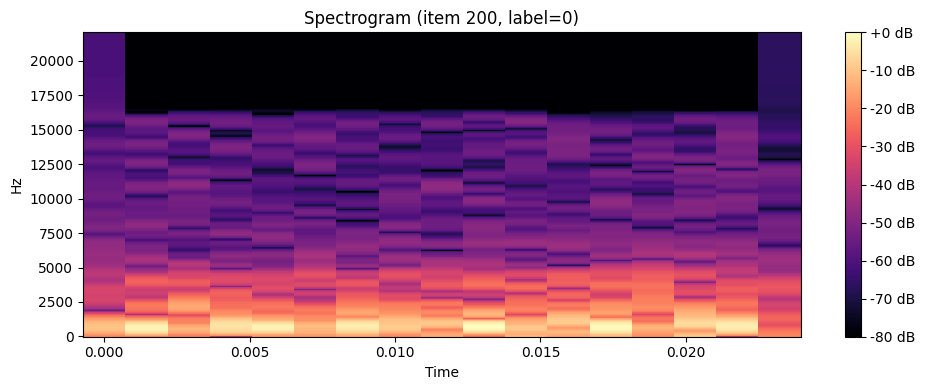

Item 200: shape=torch.Size([513, 17]), label=0

Item 670:
  Audio file: /content/audio/(02) dont kill the whale-1.wav
  Sample rate: 44100 Hz
  Waveform shape: torch.Size([2, 873180])
  Block index: 670
  Start sample: 343040
  Audio block shape: torch.Size([1024])
  Audio duration: 0.0232 seconds
  STFT parameters: n_fft=1024, hop_length=64, win_length=128
  Expected time frames: 15
  Spectrogram shape: (513, 17)


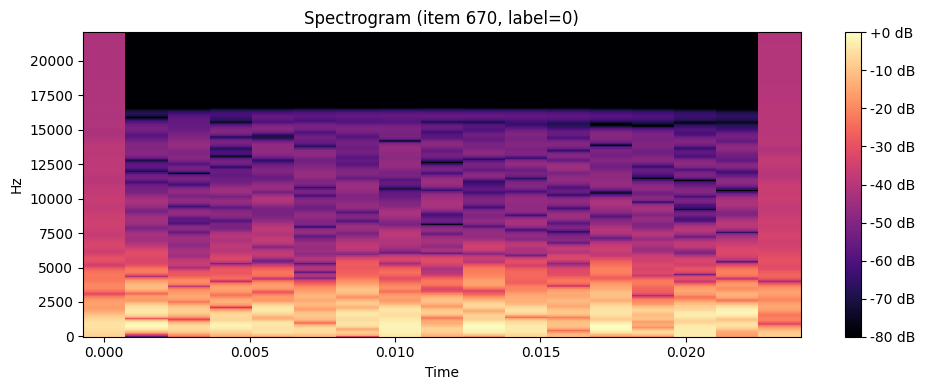

Item 670: shape=torch.Size([513, 17]), label=0

Item 900:
  Audio file: /content/audio/(02) dont kill the whale-1.wav
  Sample rate: 44100 Hz
  Waveform shape: torch.Size([2, 873180])
  Block index: 900
  Start sample: 460800
  Audio block shape: torch.Size([1024])
  Audio duration: 0.0232 seconds
  STFT parameters: n_fft=1024, hop_length=64, win_length=128
  Expected time frames: 15
  Spectrogram shape: (513, 17)


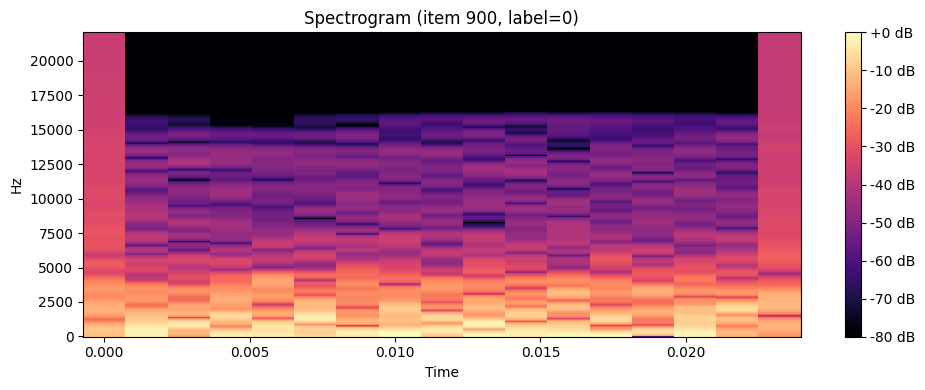

Item 900: shape=torch.Size([513, 17]), label=0

✅ DataLoaders created! Train: 979, Val: 123, Test: 123


In [19]:
def load_labels():
    """
    Extracts transient labels from JSON files without iterating over the dataset.
    Returns:
        transient_indices (list): Indices of transient blocks (label=1).
        non_transient_indices (list): Indices of non-transient blocks (label=0).
    """

    transient_indices = []
    non_transient_indices = []
    json_files = sorted([f for f in os.listdir(LABELS_DIR) if f.endswith(".json") and f != "labeling_state.json"])

    current_index = 0
    for json_file in json_files:
        with open(os.path.join(LABELS_DIR, json_file), "r") as f:
            label_data = json.load(f)

        if "transient_blocks" in label_data:
            for block in label_data["transient_blocks"]:
                if "transient" in block and block["transient"] is not None:
                    if block["transient"] == 1:
                        transient_indices.append(current_index)
                    else:
                        non_transient_indices.append(current_index)
                    current_index += 1

    print(f"Found {len(transient_indices)} transient blocks and {len(non_transient_indices)} non-transient blocks.")
    print(f"   - Transient ratio: {len(transient_indices) / (len(transient_indices) + len(non_transient_indices)) * 100:.3f}%")

    return transient_indices, non_transient_indices

def prepare_splits():
    """
    Performs stratified train-validation-test split with downsampling of non-transients.
    Returns:
        train_indices, val_indices, test_indices (list): Indices for each split.
    """
    transient_indices, non_transient_indices = load_labels()

    target_non_transients = min(len(non_transient_indices), len(transient_indices) * DOWNSAMPLE_RATIO)
    np.random.shuffle(non_transient_indices)
    downsampled_non_transient_indices = non_transient_indices[:target_non_transients]

    print(f"Downsampled non-transients from {len(non_transient_indices)} to {target_non_transients}")
    print(f"New dataset ratio: {len(transient_indices) / (len(transient_indices) + target_non_transients) * 100:.3f}% transients")

    num_val_transients = int(len(transient_indices) * VALIDATION_SPLIT)
    num_test_transients = int(len(transient_indices) * TEST_SPLIT)
    num_train_transients = len(transient_indices) - num_val_transients - num_test_transients

    num_val_non_transients = int(target_non_transients * VALIDATION_SPLIT)
    num_test_non_transients = int(target_non_transients * TEST_SPLIT)
    num_train_non_transients = target_non_transients - num_val_non_transients - num_test_non_transients

    np.random.shuffle(transient_indices)
    np.random.shuffle(downsampled_non_transient_indices)

    train_transient_indices = transient_indices[:num_train_transients]
    val_transient_indices = transient_indices[num_train_transients:num_train_transients + num_val_transients]
    test_transient_indices = transient_indices[num_train_transients + num_val_transients:]

    train_non_transient_indices = downsampled_non_transient_indices[:num_train_non_transients]
    val_non_transient_indices = downsampled_non_transient_indices[num_train_non_transients:num_train_non_transients + num_val_non_transients]
    test_non_transient_indices = downsampled_non_transient_indices[num_train_non_transients + num_val_non_transients:]

    train_indices = train_transient_indices + train_non_transient_indices
    val_indices = val_transient_indices + val_non_transient_indices
    test_indices = test_transient_indices + test_non_transient_indices

    np.random.shuffle(train_indices)
    np.random.shuffle(val_indices)
    np.random.shuffle(test_indices)

    print(f"Final splits: Train={len(train_indices)}, Validation={len(val_indices)}, Test={len(test_indices)}")
    return train_indices, val_indices, test_indices

train_indices, val_indices, test_indices = prepare_splits()

print("Loading full dataset...")
full_dataset = TransientDataset(AUDIO_DIR, LABELS_DIR)

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)
test_dataset = Subset(full_dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f" DataLoaders created! Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

In [20]:
# Initialize Model, Loss, Optimizer
print("Initializing model...")
model = TransientDetectionModel().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

Initializing model...


In [21]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience=10, lr_decay_factor=0.5, save_dir='models'):
    """
    Streamlined training function with progress tracking and model saving.
    """
    from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
    print("Starting training...")
    os.makedirs(save_dir, exist_ok=True)

    timestamp = time.strftime("%Y%m%d-%H%M%S")
    model_name = f"transient_detection_model_{timestamp}"

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=lr_decay_factor, patience=5, verbose=True)

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "train_recall": [],
        "val_recall": []
    }

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()
        train_loss, correct, total = 0.0, 0, 0
        train_preds, train_targets = [], []

        train_pbar = tqdm(train_loader, desc=f"Train {epoch+1}/{num_epochs}")
        for spectrograms, labels in train_pbar:
            spectrograms, labels = spectrograms.to(device), labels.to(device)

            if spectrograms.dim() == 3:
                spectrograms = spectrograms.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(spectrograms).squeeze()
            loss = criterion(outputs, labels.float())
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            train_preds.extend(preds.cpu().numpy())
            train_targets.extend(labels.cpu().numpy())

            train_pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'acc': f"{(preds == labels).sum().item() / labels.size(0):.4f}"
            })

        train_acc = correct / total
        avg_train_loss = train_loss / len(train_loader)
        train_recall = recall_score(train_targets, train_preds)
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["train_recall"].append(train_recall)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_targets = [], []

        val_pbar = tqdm(val_loader, desc=f"Valid {epoch+1}/{num_epochs}")
        with torch.no_grad():
            for spectrograms, labels in val_pbar:
                spectrograms, labels = spectrograms.to(device), labels.to(device)

                if spectrograms.dim() == 3:
                    spectrograms = spectrograms.unsqueeze(1)

                outputs = model(spectrograms).squeeze()
                loss = criterion(outputs, labels.float())

                val_loss += loss.item()
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_preds.extend(preds.cpu().numpy())
                val_targets.extend(labels.cpu().numpy())

                val_pbar.set_postfix({
                    'loss': f"{loss.item():.4f}",
                    'acc': f"{(preds == labels).sum().item() / labels.size(0):.4f}"
                })

        val_acc = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)
        val_recall = recall_score(val_targets, val_preds)
        history["val_loss"].append(avg_val_loss)
        history["val_acc"].append(val_acc)
        history["val_recall"].append(val_recall)

        print(f"\nEpoch Summary:")
        print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Train Recall: {train_recall:.4f}")
        print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, Val Recall: {val_recall:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print("New best model found!")

            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'history': history
            }, f"{save_dir}/{model_name}_best.pth")
            print(f"Saved best model to {save_dir}/{model_name}_best.pth")

        else:
            patience_counter += 1
            print(f"No improvement in {patience_counter}/{patience} epochs.")

        scheduler.step(avg_val_loss)

        if patience_counter >= patience:
            print("\nEarly stopping triggered. Restoring best model.")
            model.load_state_dict(best_model_state)
            break

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
                'history': history
            }, f"{save_dir}/{model_name}_epoch_{epoch+1}.pth")
            print(f"Saved checkpoint to {save_dir}/{model_name}_epoch_{epoch+1}.pth")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label='Train Loss')
    plt.plot(history["val_loss"], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label='Train Accuracy')
    plt.plot(history["val_acc"], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{save_dir}/{model_name}_history.png')
    plt.show()

    print("\nTraining complete!")

    model.load_state_dict(best_model_state)
    model.eval()
    final_val_preds, final_val_targets = [], []

    print("Running final evaluation...")
    with torch.no_grad():
        for spectrograms, labels in tqdm(val_loader, desc="Final evaluation"):
            spectrograms, labels = spectrograms.to(device), labels.to(device)

            if spectrograms.dim() == 3:
                spectrograms = spectrograms.unsqueeze(1)

            outputs = model(spectrograms).squeeze()
            preds = (outputs > 0.5).float()

            final_val_preds.extend(preds.cpu().numpy())
            final_val_targets.extend(labels.cpu().numpy())

    cm = confusion_matrix(final_val_targets, final_val_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm) 

    # Plot normalized confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.title('Normalized Confusion Matrix')
    plt.colorbar(label='Percentage')
    plt.xticks([0, 1], ['Non-Transient', 'Transient'])
    plt.yticks([0, 1], ['Non-Transient', 'Transient'])

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%",
                     horizontalalignment="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig(f'{save_dir}/{model_name}_confusion_matrix.png')
    plt.show()

    print("Confusion Matrix (Raw Counts):")
    print(cm)

    from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

    print("\nFinal Metrics:")
    f1 = f1_score(final_val_targets, final_val_preds)
    precision = precision_score(final_val_targets, final_val_preds)
    recall = recall_score(final_val_targets, final_val_preds)

    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    print("\nClassification Report:")
    print(classification_report(final_val_targets, final_val_preds,
                               target_names=['Non-Transient', 'Transient']))

    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_loss': best_val_loss,  # Use best val loss
        'val_acc': val_acc,
        'val_f1': f1,
        'val_precision': precision,
        'val_recall': recall,
        'history': history,
        'confusion_matrix': cm.tolist()
    }, f"{save_dir}/{model_name}_final.pth")

    metadata = {
        "model_name": model_name,
        "timestamp": timestamp,
        "num_epochs": epoch + 1,
        "early_stopping_patience": patience,
        "lr_decay_factor": lr_decay_factor,
        "final_metrics": {
            "f1_score": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "val_loss": float(best_val_loss),
            "val_accuracy": float(val_acc)
        },
        "confusion_matrix": cm.tolist()
    }

    with open(f"{save_dir}/{model_name}_metadata.json", 'w') as f:
        json.dump(metadata, f, indent=4)

    print(f"Model saved to {save_dir}/{model_name}_final.pth")
    print(f"Metadata saved to {save_dir}/{model_name}_metadata.json")

    return history, best_model_state

Starting training...

Epoch 1/100


Valid 1/100: 100%|██████████| 123/123 [01:28<00:00,  1.39it/s, loss=0.1052, acc=1.0000]



Epoch Summary:
Train Loss: 0.1002, Train Acc: 0.9719, Train Recall: 0.6939
Val Loss: 0.0623, Val Acc: 0.9785, Val Recall: 0.8770
New best model found!
Saved best model to models/transient_detection_model_20250311-042502_best.pth

Epoch 2/100


Valid 2/100: 100%|██████████| 123/123 [01:27<00:00,  1.40it/s, loss=0.0397, acc=1.0000]



Epoch Summary:
Train Loss: 0.0634, Train Acc: 0.9781, Train Recall: 0.8160
Val Loss: 0.0559, Val Acc: 0.9808, Val Recall: 0.8566
New best model found!
Saved best model to models/transient_detection_model_20250311-042502_best.pth

Epoch 3/100


...


Epoch Summary:
Train Loss: 0.0266, Train Acc: 0.9902, Train Recall: 0.9249
Val Loss: 0.0677, Val Acc: 0.9780, Val Recall: 0.8115
No improvement in 8/10 epochs.

Epoch 17/100


Valid 17/100: 100%|██████████| 123/123 [01:25<00:00,  1.44it/s, loss=0.1562, acc=0.8571]



Epoch Summary:
Train Loss: 0.0230, Train Acc: 0.9913, Train Recall: 0.9315
Val Loss: 0.0644, Val Acc: 0.9788, Val Recall: 0.8197
No improvement in 9/10 epochs.

Epoch 18/100


Valid 18/100: 100%|██████████| 123/123 [01:26<00:00,  1.42it/s, loss=0.3520, acc=0.8571]



Epoch Summary:
Train Loss: 0.0213, Train Acc: 0.9929, Train Recall: 0.9438
Val Loss: 0.0801, Val Acc: 0.9757, Val Recall: 0.7459
No improvement in 10/10 epochs.

Early stopping triggered. Restoring best model.


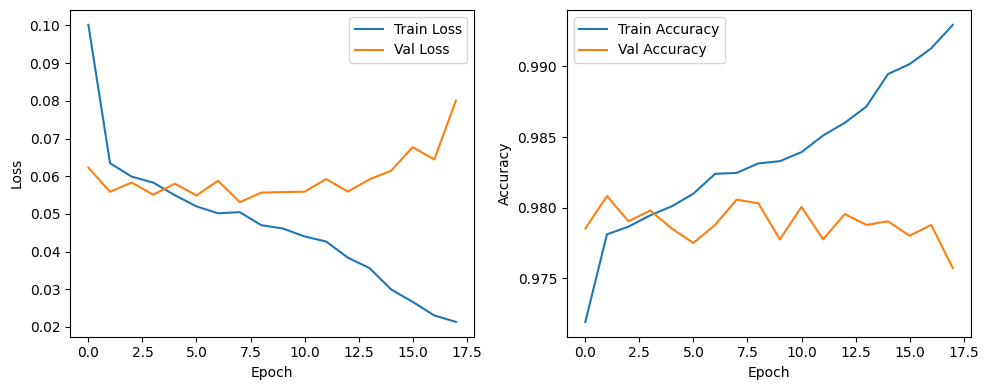


Training complete!
Running final evaluation...


Final evaluation: 100%|██████████| 123/123 [01:25<00:00,  1.43it/s]


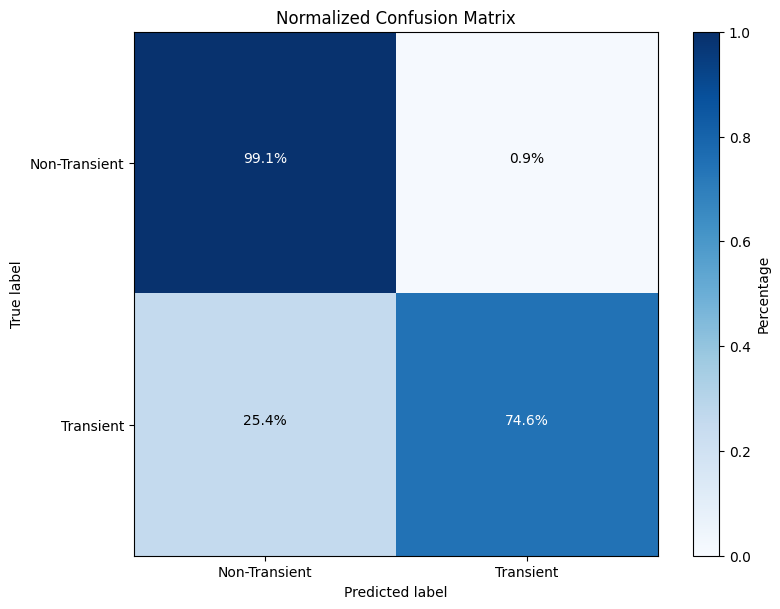

Confusion Matrix (Raw Counts):
[[3634   33]
 [  62  182]]

Final Metrics:
F1 Score: 0.7930
Precision: 0.8465
Recall: 0.7459

Classification Report:
               precision    recall  f1-score   support

Non-Transient       0.98      0.99      0.99      3667
    Transient       0.85      0.75      0.79       244

     accuracy                           0.98      3911
    macro avg       0.91      0.87      0.89      3911
 weighted avg       0.97      0.98      0.97      3911

Model saved to models/transient_detection_model_20250311-042502_final.pth
Metadata saved to models/transient_detection_model_20250311-042502_metadata.json


In [22]:
history, best_model_state = train_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS)

Evaluating best model: 100%|██████████| 123/123 [01:28<00:00,  1.38it/s]



Final Evaluation Metrics:
F1 Score: 0.8263
Precision: 0.8553
Recall: 0.7992

Classification Report:
               precision    recall  f1-score   support

Non-Transient       0.99      0.99      0.99      3667
    Transient       0.86      0.80      0.83       244

     accuracy                           0.98      3911
    macro avg       0.92      0.90      0.91      3911
 weighted avg       0.98      0.98      0.98      3911



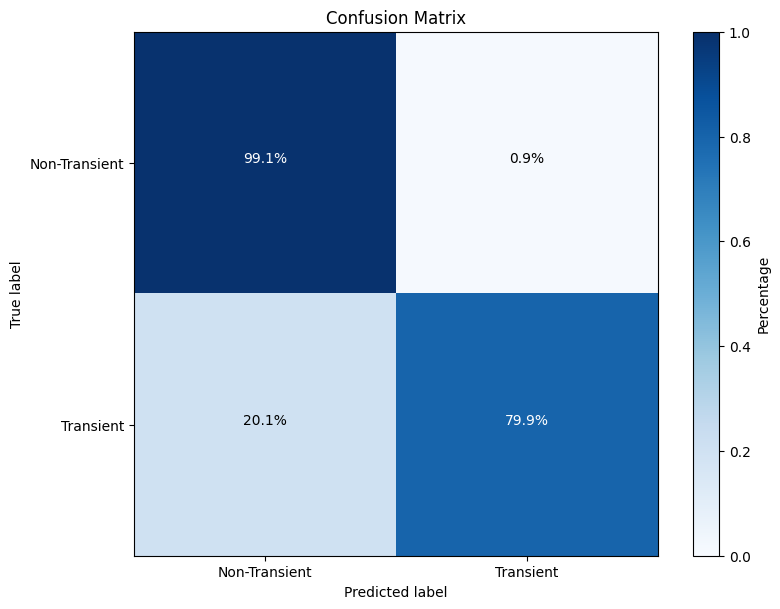

In [23]:
model.load_state_dict(best_model_state)

model.eval()
test_preds, test_targets = [], []

with torch.no_grad():
    for spectrograms, labels in tqdm(test_loader, desc="Evaluating best model"):
        spectrograms, labels = spectrograms.to(device), labels.to(device)

        if spectrograms.dim() == 3:
            spectrograms = spectrograms.unsqueeze(1)

        outputs = model(spectrograms).squeeze()
        preds = (outputs > 0.5).float()

        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(labels.cpu().numpy())

print("\nFinal Evaluation Metrics:")
print(f"F1 Score: {f1_score(test_targets, test_preds):.4f}")
print(f"Precision: {precision_score(test_targets, test_preds):.4f}")
print(f"Recall: {recall_score(test_targets, test_preds):.4f}")

print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=['Non-Transient', 'Transient']))

cm = confusion_matrix(test_targets, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)  

plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=1)
plt.title('Confusion Matrix')
plt.colorbar(label='Percentage')
plt.xticks([0, 1], ['Non-Transient', 'Transient'])
plt.yticks([0, 1], ['Non-Transient', 'Transient'])

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(j, i, f"{cm_norm[i, j]*100:.1f}%",
                  horizontalalignment="center",
                  color="white" if cm_norm[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.savefig('confusion_matrix.png')
plt.show()

In [29]:
! zip -r models.zip /content/models

  adding: content/models/ (stored 0%)
  adding: content/models/transient_detection_model_20250311-042502_final.pth (deflated 9%)
  adding: content/models/transient_detection_model_20250311-042502_metadata.json (deflated 49%)
  adding: content/models/transient_detection_model_20250311-042502_confusion_matrix.png (deflated 17%)
  adding: content/models/transient_detection_model_20250311-040650_best.pth (deflated 9%)
  adding: content/models/transient_detection_model_20250311-042502_best.pth (deflated 9%)
  adding: content/models/transient_detection_model_20250311-042502_epoch_10.pth (deflated 9%)
  adding: content/models/transient_detection_model_20250311-042502_history.png (deflated 6%)
